# 🏠 House Prices — Model Comparison & Ensemble

**Goal:** Compare all trained models, visualize performance, build an ensemble (blending),
and generate the best possible Kaggle submission.

| Model | CV RMSLE | Std |
|-------|----------|-----|
| Lasso | 0.10979 | ±0.00745 |
| Ridge | 0.11196 | ±0.00846 |
| XGBoost | 0.11653 | ±0.00430 |
| Random Forest | 0.13133 | ±0.00787 |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model   import Ridge, Lasso
from sklearn.pipeline       import make_pipeline
from sklearn.preprocessing  import RobustScaler
from sklearn.ensemble       import RandomForestRegressor
from sklearn.metrics        import root_mean_squared_error, r2_score
from xgboost                import XGBRegressor

sns.set_style("whitegrid")


## 1. Load Data

In [2]:
X          = pd.read_csv("../data/train_final.csv")
y          = pd.read_csv("../data/target.csv").squeeze()   # log1p(SalePrice)
test_final = pd.read_csv("../data/test_final.csv")
test_ids   = pd.read_csv("../data/test_ids.csv").squeeze()

print("X shape        :", X.shape)
print("y shape        :", y.shape)
print("test_final     :", test_final.shape)


X shape        : (1458, 297)
y shape        : (1458,)
test_final     : (1459, 297)


## 2. Define All Models

In [3]:
models = {
    "Lasso": make_pipeline(
        RobustScaler(),
        Lasso(alpha=0.0005, max_iter=10000)
    ),
    "Ridge": make_pipeline(
        RobustScaler(),
        Ridge(alpha=10)
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=3,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, objective="reg:squarederror", verbosity=0
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_features=0.5,
        random_state=42, n_jobs=-1
    ),
}
print("Models defined:", list(models.keys()))


Models defined: ['Lasso', 'Ridge', 'XGBoost', 'Random Forest']


## 3. Cross-Validation Comparison

5-Fold CV → most reliable score. This maps directly to Kaggle RMSLE since `y` is already log-transformed.


In [4]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    scores = -cross_val_score(
        model, X, y, cv=kf,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    cv_results.append({
        "Model"      : name,
        "CV RMSLE"   : round(scores.mean(), 5),
        "Std"        : round(scores.std(),  5),
        "Best Fold"  : round(scores.min(),  5),
        "Worst Fold" : round(scores.max(),  5),
    })
    print(f"{name:20s} | CV RMSLE: {scores.mean():.5f} ± {scores.std():.5f}")

cv_df = pd.DataFrame(cv_results).sort_values("CV RMSLE").reset_index(drop=True)
print()
print(cv_df.to_string(index=False))


Lasso                | CV RMSLE: 0.10979 ± 0.00745
Ridge                | CV RMSLE: 0.11196 ± 0.00846
XGBoost              | CV RMSLE: 0.11582 ± 0.00581
Random Forest        | CV RMSLE: 0.13133 ± 0.00787

        Model  CV RMSLE     Std  Best Fold  Worst Fold
        Lasso   0.10979 0.00745    0.09681     0.11798
        Ridge   0.11196 0.00846    0.09688     0.12091
      XGBoost   0.11582 0.00581    0.10622     0.12050
Random Forest   0.13133 0.00787    0.12247     0.14061


## 4. Visualize CV Results

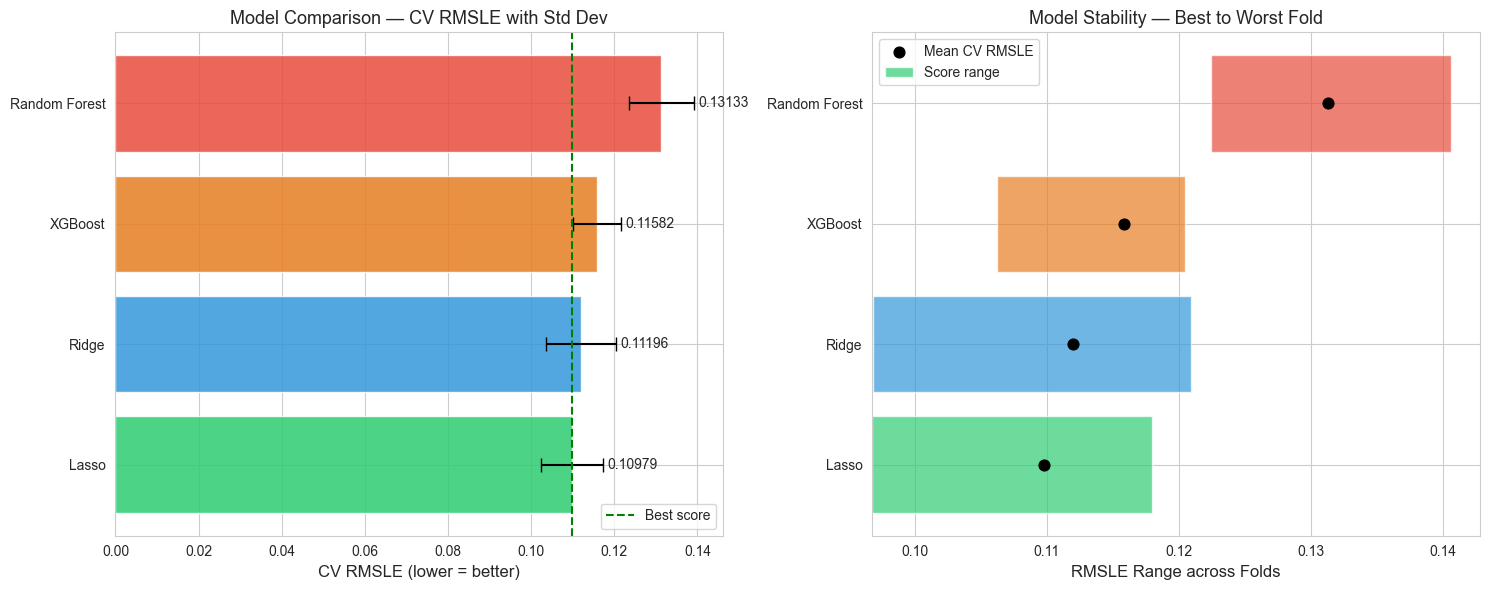

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Chart 1: CV RMSLE bar with error bars ──
colors = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c"]
axes[0].barh(
    cv_df["Model"], cv_df["CV RMSLE"],
    xerr=cv_df["Std"], color=colors,
    align="center", alpha=0.85, ecolor="black", capsize=5
)
axes[0].axvline(cv_df["CV RMSLE"].min(), color="green", linestyle="--", lw=1.5, label="Best score")
axes[0].set_xlabel("CV RMSLE (lower = better)", fontsize=12)
axes[0].set_title("Model Comparison — CV RMSLE with Std Dev", fontsize=13)
axes[0].legend()
for i, (rmsle, std) in enumerate(zip(cv_df["CV RMSLE"], cv_df["Std"])):
    axes[0].text(rmsle + std + 0.001, i, f"{rmsle:.5f}", va="center", fontsize=10)

# ── Chart 2: Best vs Worst fold range ──
axes[1].barh(cv_df["Model"], cv_df["Worst Fold"] - cv_df["Best Fold"],
             left=cv_df["Best Fold"], color=colors, alpha=0.7, label="Score range")
axes[1].scatter(cv_df["CV RMSLE"], cv_df["Model"],
                color="black", zorder=5, s=60, label="Mean CV RMSLE")
axes[1].set_xlabel("RMSLE Range across Folds", fontsize=12)
axes[1].set_title("Model Stability — Best to Worst Fold", fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/plots/cv_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Fit All Models on Full Training Data

Fit on **all** X (not just train split) for best test predictions.


In [6]:
fitted_models = {}

for name, model in models.items():
    model.fit(X, y)
    fitted_models[name] = model
    print(f"✅ {name} fitted.")


✅ Lasso fitted.
✅ Ridge fitted.
✅ XGBoost fitted.
✅ Random Forest fitted.


## 6. Ensemble — Weighted Blending

**Why blend?**
- Single model may overfit on certain patterns
- Lasso captures linear relationships well
- XGBoost captures non-linear patterns
- Blending averages their errors → lower RMSLE

**Weights based on CV performance:**
- Lasso (best) → highest weight
- Ridge → second weight  
- XGBoost → third weight
- Random Forest → excluded (worst CV score, high variance)


In [7]:
# Individual test predictions (log scale)
preds = {}
for name, model in fitted_models.items():
    preds[name] = model.predict(test_final)

# Weighted blend — weights sum to 1.0
# Higher weight → better CV score
weights = {
    "Lasso"        : 0.45,
    "Ridge"        : 0.30,
    "XGBoost"      : 0.25,
    "Random Forest": 0.00,   # excluded
}

blend_log = sum(weights[name] * preds[name] for name in weights)

print("Blend weights:")
for name, w in weights.items():
    if w > 0:
        print(f"  {name:15s}: {w}")


Blend weights:
  Lasso          : 0.45
  Ridge          : 0.3
  XGBoost        : 0.25


## 7. Validate Blend on Train Data (OOF Predictions)

Out-of-Fold (OOF) blending — each fold's val predictions are never seen during training → unbiased estimate.

In [8]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_lasso = np.zeros(len(X))
oof_ridge = np.zeros(len(X))
oof_xgb   = np.zeros(len(X))

lasso_pipe = make_pipeline(RobustScaler(), Lasso(alpha=0.0005, max_iter=10000))
ridge_pipe = make_pipeline(RobustScaler(), Ridge(alpha=10))
xgb_m      = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=3,
                           subsample=0.8, colsample_bytree=0.8,
                           random_state=42, objective="reg:squarederror", verbosity=0)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    lasso_pipe.fit(X_tr, y_tr);  oof_lasso[val_idx] = lasso_pipe.predict(X_val)
    ridge_pipe.fit(X_tr, y_tr);  oof_ridge[val_idx] = ridge_pipe.predict(X_val)
    xgb_m.fit(X_tr, y_tr);       oof_xgb[val_idx]   = xgb_m.predict(X_val)

    print(f"Fold {fold+1} done.")

oof_blend = 0.45 * oof_lasso + 0.30 * oof_ridge + 0.25 * oof_xgb

print()
print(f"OOF RMSLE — Lasso  : {root_mean_squared_error(y, oof_lasso):.5f}")
print(f"OOF RMSLE — Ridge  : {root_mean_squared_error(y, oof_ridge):.5f}")
print(f"OOF RMSLE — XGBoost: {root_mean_squared_error(y, oof_xgb):.5f}")
print(f"OOF RMSLE — Blend  : {root_mean_squared_error(y, oof_blend):.5f}  ← Expected Kaggle score")


Fold 1 done.
Fold 2 done.
Fold 3 done.
Fold 4 done.
Fold 5 done.

OOF RMSLE — Lasso  : 0.11005
OOF RMSLE — Ridge  : 0.11228
OOF RMSLE — XGBoost: 0.11661
OOF RMSLE — Blend  : 0.10858  ← Expected Kaggle score


## 8. Blend vs Individual — Visual Comparison

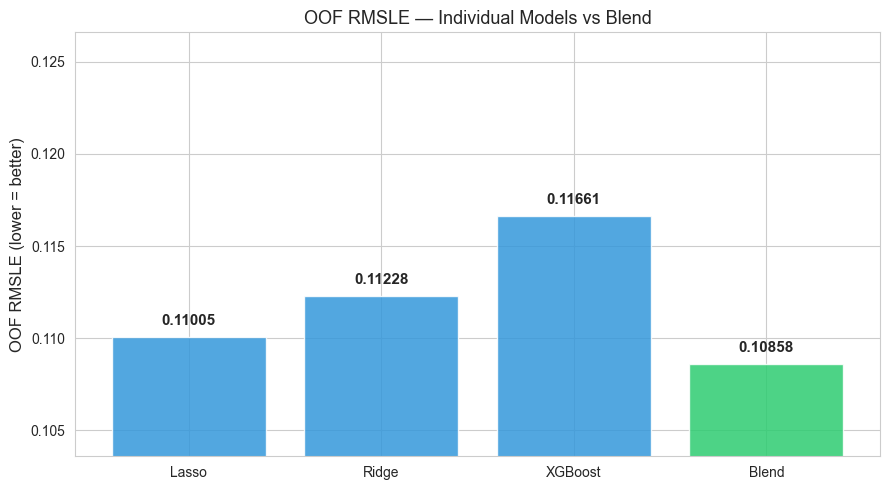

In [9]:
model_names  = ["Lasso", "Ridge", "XGBoost", "Blend"]
oof_scores   = [
    root_mean_squared_error(y, oof_lasso),
    root_mean_squared_error(y, oof_ridge),
    root_mean_squared_error(y, oof_xgb),
    root_mean_squared_error(y, oof_blend),
]

colors_bar = ["#3498db", "#3498db", "#3498db", "#2ecc71"]

plt.figure(figsize=(9, 5))
bars = plt.bar(model_names, oof_scores, color=colors_bar, alpha=0.85, edgecolor="white")
plt.ylabel("OOF RMSLE (lower = better)", fontsize=12)
plt.title("OOF RMSLE — Individual Models vs Blend", fontsize=13)

for bar, score in zip(bars, oof_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.0005,
             f"{score:.5f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.ylim(min(oof_scores) - 0.005, max(oof_scores) + 0.01)
plt.tight_layout()
plt.savefig("../outputs/plots/blend_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Generate Kaggle Submissions

Create 2 files — best single model (Lasso) + blend. Submit both and compare.

In [10]:
import os
os.makedirs("../submissions", exist_ok=True)

# ── Submission 1: Lasso only (best single model) ──
lasso_test_pred = np.expm1(preds["Lasso"])
sub_lasso = pd.DataFrame({"Id": test_ids, "SalePrice": lasso_test_pred})
sub_lasso.to_csv("../submissions/submission_lasso.csv", index=False)
print("✅ submission_lasso.csv created")
print(f"   SalePrice range: ${lasso_test_pred.min():,.0f} — ${lasso_test_pred.max():,.0f}")

print()

# ── Submission 2: Weighted Blend ──
blend_pred = np.expm1(blend_log)
sub_blend  = pd.DataFrame({"Id": test_ids, "SalePrice": blend_pred})
sub_blend.to_csv("../submissions/submission_blend.csv", index=False)
print("✅ submission_blend.csv created")
print(f"   SalePrice range: ${blend_pred.min():,.0f} — ${blend_pred.max():,.0f}")


✅ submission_lasso.csv created
   SalePrice range: $42,150 — $870,392

✅ submission_blend.csv created
   SalePrice range: $42,303 — $790,831


## 10. Summary & Kaggle Strategy

In [11]:
summary = pd.DataFrame({
    "Model"            : ["Lasso", "Ridge", "XGBoost", "Random Forest", "Blend (45/30/25)"],
    "CV RMSLE"         : [0.10979, 0.11196, 0.11653, 0.13133, "→ check OOF above"],
    "Submit?"          : ["✅ Yes (primary)", "⬜ Optional", "⬜ Optional", "❌ No", "✅ Yes (secondary)"],
})

print(summary.to_string(index=False))
print()
print("─" * 55)
print("📌 KAGGLE STRATEGY:")
print("  1. Submit submission_lasso.csv first")
print("  2. Check public leaderboard score")
print("  3. Submit submission_blend.csv")
print("  4. If blend < lasso score → use blend as final")
print("  5. Target: Public RMSLE < 0.13 → Top 30%")
print("             Public RMSLE < 0.12 → Top 20%")
print("             Public RMSLE < 0.115→ Top 15%")
print("─" * 55)


           Model          CV RMSLE           Submit?
           Lasso           0.10979   ✅ Yes (primary)
           Ridge           0.11196        ⬜ Optional
         XGBoost           0.11653        ⬜ Optional
   Random Forest           0.13133              ❌ No
Blend (45/30/25) → check OOF above ✅ Yes (secondary)

───────────────────────────────────────────────────────
📌 KAGGLE STRATEGY:
  1. Submit submission_lasso.csv first
  2. Check public leaderboard score
  3. Submit submission_blend.csv
  4. If blend < lasso score → use blend as final
  5. Target: Public RMSLE < 0.13 → Top 30%
             Public RMSLE < 0.12 → Top 20%
             Public RMSLE < 0.115→ Top 15%
───────────────────────────────────────────────────────
